Ruta base del proyecto: c:\Users\gabri\OneDrive\Documentos\GitHub\trabajo_ciencia
Buscando base de datos en: c:\Users\gabri\OneDrive\Documentos\GitHub\trabajo_ciencia\data\raw\database.sqlite

--- REPORTE DE INTEGRIDAD ---
Estado: OK
Tamaño: 79.71 MB
MD5 (Checksum): d8e0296867e21780abf02d9cd65a60da

--- REPORTE DE INTEGRACIÓN Y OPTIMIZACIÓN ---
Tablas unificadas: 6
Ahorro de memoria: 1.08%
Dimensiones finales: (18389, 18)


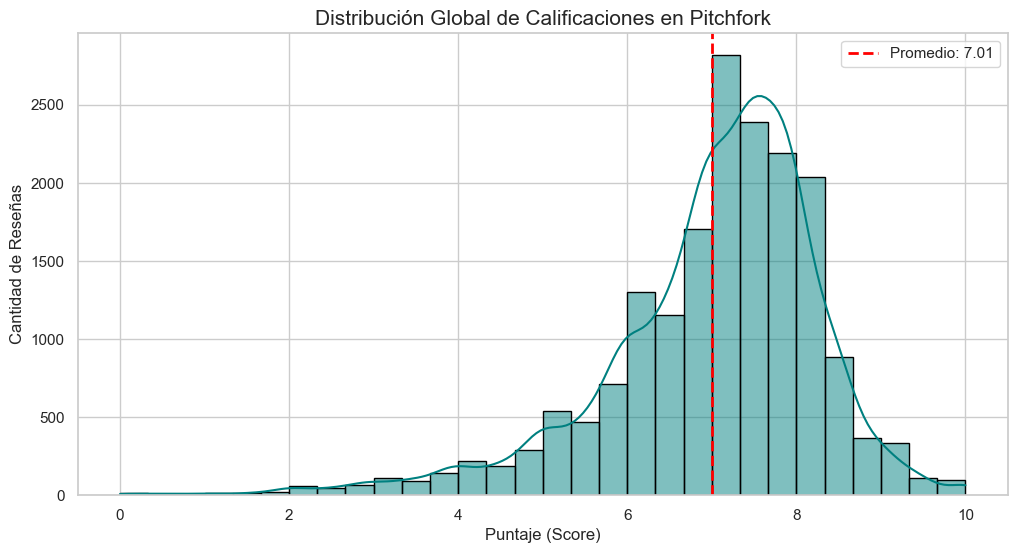

Archivo generado con éxito en: c:\Users\gabri\OneDrive\Documentos\GitHub\trabajo_ciencia\data\processed\pitchfork_processed.csv
Muestra de datos finales:


,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year,genre,label,year,content,artist_extra
0,22703,mezzanine,massive attack,http://pitchfork.com/reviews/albums/22703-mezz...,9.3,0,nate patrin,contributor,2017-01-08,6,8,1,2017,electronic,virgin,1998.0,"“Trip-hop” eventually became a ’90s punchline,...",massive attack
1,22721,prelapsarian,krallice,http://pitchfork.com/reviews/albums/22721-prel...,7.9,0,zoe camp,contributor,2017-01-07,5,7,1,2017,metal,hathenter,2016.0,"Eight years, five albums, and two EPs in, the ...",krallice
2,22659,all of them naturals,uranium club,http://pitchfork.com/reviews/albums/22659-all-...,7.3,0,david glickman,contributor,2017-01-07,5,7,1,2017,rock,static shock,2016.0,Minneapolis’ Uranium Club seem to revel in bei...,uranium club
4,22661,first songs,"kleenex, liliput",http://pitchfork.com/reviews/albums/22661-firs...,9.0,1,jenn pelly,associate reviews editor,2017-01-06,4,6,1,2017,rock,kill rock stars,2016.0,Kleenex began with a crash. It transpired one ...,kleenex
8,22725,new start,taso,http://pitchfork.com/reviews/albums/22725-new-...,8.1,0,kevin lozano,tracks coordinator,2017-01-06,4,6,1,2017,electronic,teklife,2016.0,It is impossible to consider a given release b...,taso


In [1]:
# =================================================================
# PROYECTO: ANÁLISIS INTEGRAL DE PITCHFORK
# ETAPA: Extracción, Limpieza Multitabla y Optimización
# =================================================================

# 1. IMPORTS Y CONFIGURACIÓN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import hashlib

# Configuración de visualización profesional
%matplotlib inline
sns.set_theme(style="whitegrid")

# 2. DEFINIR RUTA ROBUSTA
# Se utiliza la lógica de carpetas para subir un nivel desde /notebooks
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base_dir, 'data', 'raw', 'database.sqlite')

print(f"Ruta base del proyecto: {base_dir}")
print(f"Buscando base de datos en: {db_path}")

# 3. VERIFICACIÓN DE INTEGRIDAD
def verificar_integridad(ruta):
    """
    Auditoría técnica mediante MD5 para asegurar la validez del archivo fuente.
    """
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"Error Crítico: No se encontró el archivo en {ruta}")

    size_mb = os.path.getsize(ruta) / (1024 * 1024)
    with open(ruta, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    print("\n--- REPORTE DE INTEGRIDAD ---")
    print(f"Estado: OK")
    print(f"Tamaño: {size_mb:.2f} MB")
    print(f"MD5 (Checksum): {file_hash}")
    return True

verificar_integridad(db_path)

# 4. CARGA, LIMPIEZA INTEGRAL (6 TABLAS) Y OPTIMIZACIÓN
def cargar_dataset_maestro(path):
    conn = sqlite3.connect(path)
    
    # A. Carga y limpieza individual por tabla (Separación de preocupaciones)
    
    # Reviews: Tabla base
    df_rev = pd.read_sql_query("SELECT * FROM reviews", conn)
    
    # Genres: Imputación de nulos y normalización de texto
    df_gen = pd.read_sql_query("SELECT * FROM genres", conn)
    df_gen['genre'] = df_gen['genre'].fillna('unassigned').str.strip().str.lower()
    
    # Labels: Limpieza de espacios y manejo de nulos
    df_lab = pd.read_sql_query("SELECT * FROM labels", conn)
    df_lab['label'] = df_lab['label'].fillna('independent').str.strip()
    
    # Content: Limpieza de caracteres invisibles en el texto de la reseña
    df_con = pd.read_sql_query("SELECT * FROM content", conn)
    df_con['content'] = df_con['content'].str.strip()
    
    # Artists y Years: Datos de apoyo
    df_art = pd.read_sql_query("SELECT * FROM artists", conn)
    df_art['artist'] = df_art['artist'].str.strip()
    df_yrs = pd.read_sql_query("SELECT * FROM years", conn)
    
    conn.close()

    # B. Integración mediante Joins Complejos (Punto 1 y 3 de la rúbrica)
    df = df_rev.merge(df_gen, on='reviewid', how='left')
    df = df.merge(df_lab, on='reviewid', how='left')
    df = df.merge(df_yrs, on='reviewid', how='left')
    df = df.merge(df_con, on='reviewid', how='left')
    df = df.merge(df_art, on='reviewid', how='left', suffixes=('', '_extra'))

    # C. Limpieza Técnica Final
    # Eliminación de duplicados por relación 1:N (Géneros múltiples)
    df = df.drop_duplicates(subset=['reviewid']).copy()
    
    # D. Optimización de Memoria (Downcasting)
    mem_ini = df.memory_usage(deep=True).sum() / (1024**2)
    
    df['score'] = df['score'].astype('float32') # Reducción de 64 a 32 bits
    df['pub_year'] = pd.to_numeric(df['pub_year'], downcast='integer')
    df['genre'] = df['genre'].astype('category') # Optimización de texto repetitivo
    
    mem_fin = df.memory_usage(deep=True).sum() / (1024**2)

    print("\n--- REPORTE DE INTEGRACIÓN Y OPTIMIZACIÓN ---")
    print(f"Tablas unificadas: 6")
    print(f"Ahorro de memoria: {((mem_ini - mem_fin)/mem_ini)*100:.2f}%")
    print(f"Dimensiones finales: {df.shape}")

    return df

df = cargar_dataset_maestro(db_path)

# 5. VISUALIZACIÓN DE RESULTADOS
plt.figure(figsize=(12, 6))
sns.histplot(df['score'], bins=30, kde=True, color='teal', edgecolor='black')

media = df['score'].mean()
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Promedio: {media:.2f}")

plt.title('Distribución Global de Calificaciones en Pitchfork', fontsize=15)
plt.xlabel('Puntaje (Score)', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)
plt.legend()
plt.show()

# 6. EXPORTACIÓN A PROCESSED (Persistencia de datos)
processed_dir = os.path.join(base_dir, 'data', 'processed')

if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)
    print(f"Carpeta creada: {processed_dir}")

out_path = os.path.join(processed_dir, 'pitchfork_processed.csv')
df.to_csv(out_path, index=False)

print(f"Archivo generado con éxito en: {out_path}")
print(f"Muestra de datos finales:")
display(df.head())